# Notebook 09 — Model Explainability and Interpretation

This notebook analyzes why the model makes its predictions.

At this stage, the machine learning pipeline already includes:

+ Data preprocessing

+ Feature engineering

+ Gradient boosting models

+ Ensemble learning

 Feature selection

+ Model optimization

However, machine learning models — especially ensemble models — can behave like black boxes.

Explainable AI (XAI) techniques help answer questions such as:

+ Which features most influence predictions?

+ How does each feature affect the probability of each class?

 Why was a particular SME predicted as Low, Medium, or High financial health?

This notebook performs both:

**Global explainability**

+ Understanding overall model behavior.

**Local explainability**

+ Understanding individual predictions.

The analysis uses:

+ Feature importance from trained models

+ Permutation importance

+ SHAP (SHapley Additive Explanations)

In [2]:
# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

import joblib

from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [3]:
# Load Data and Models from Previous Notebook


# Load datasets
X_final = pd.read_pickle("data/X_final.pkl")
y = pd.read_pickle("data/y.pkl")
test_final = pd.read_pickle("data/test_final.pkl")

# Load models

cat_model = joblib.load("models/catboost_final.pkl")
lgb_model = joblib.load("models/lightgbm_final.pkl")

# Load predictions
oof_blend = pd.read_pickle("models/oof_blend.pkl")
final_preds = pd.read_pickle("models/final_preds.pkl")

In [4]:
# Global feature importance - Catboost

cat_importance = cat_model.get_feature_importance()

cat_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": cat_importance
}).sort_values("importance", ascending=False)

cat_df.head(20)

,feature,importance
0,funeral_insurance,21.337332
36,uses_friends_family_savings,3.530429
73,has_loan_account,3.524051
78,has_debit_card,3.508334
2,owner_age,3.221464
4,turnover_to_personal_income,2.971657
15,has_insurance,2.905156
31,has_credit_card,2.619509
13,country_x_has_loan_account,2.426717
14,business_age_years,2.165313


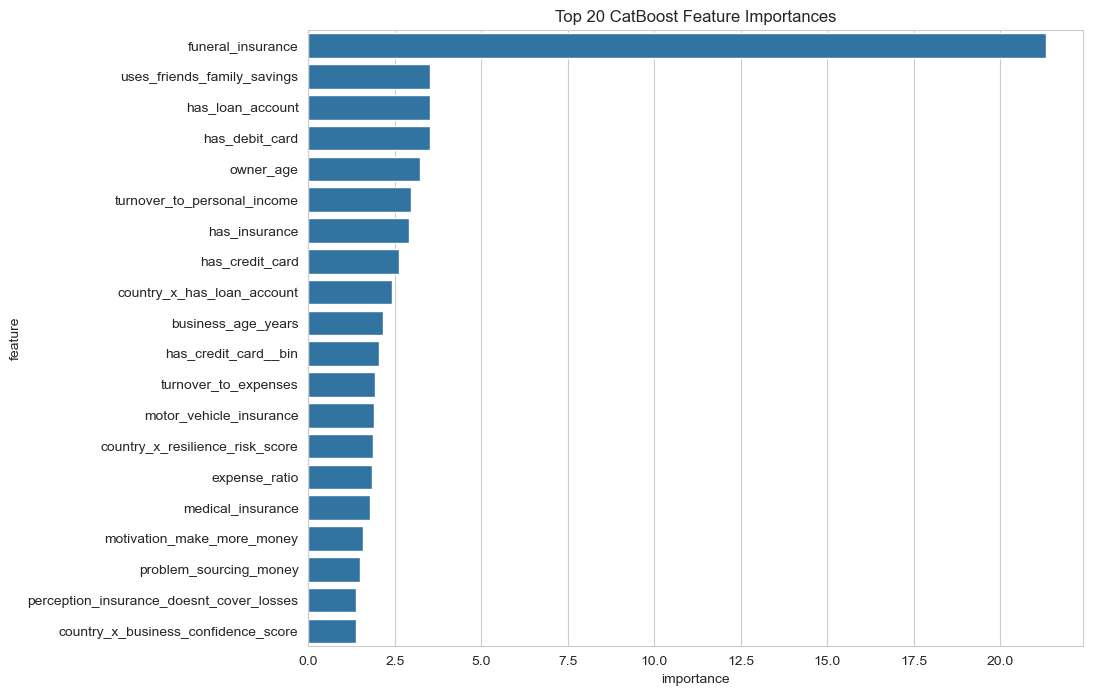

In [5]:
# visualize 

plt.figure(figsize=(10,8))

sns.barplot(
    data=cat_df.head(20),
    y="feature",
    x="importance"
)

plt.title("Top 20 CatBoost Feature Importances")
plt.show()

### CatBoost Feature Importance — Interpretation

The CatBoost model identifies **insurance-related variables as the most influential predictors of SME financial health**, with *funeral insurance* emerging as the single most dominant feature by a significant margin.

This indicates that SMEs with access to insurance products are more likely to exhibit stronger financial resilience. Insurance coverage reflects the ability of businesses to mitigate risk and absorb financial shocks, which aligns closely with the conceptual definition of financial health.

In addition to insurance, the model also emphasizes:

- Financial access indicators (loan accounts, debit cards)
- Informal financial behavior (use of savings from friends/family)
- Business performance measures (income ratios)
- Business maturity (owner age, business age)

The strong dominance of funeral insurance suggests that **risk protection mechanisms are a critical determinant of SME financial stability** in the dataset.

However, the large gap between the top feature and others also indicates that the model may rely heavily on a small subset of highly predictive variables.

In [6]:
# Global feature importance - LightGBM

lgb_importance = lgb_model.feature_importances_

lgb_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": lgb_importance
}).sort_values("importance", ascending=False)

lgb_df.head(20)

,feature,importance
2,owner_age,39792
4,turnover_to_personal_income,38027
5,personal_income,29868
6,business_expenses,29058
14,business_age_years,28282
8,expense_ratio,26450
9,margin_proxy,24789
12,turnover_to_expenses,21618
11,business_turnover,20570
16,business_age_months,13314


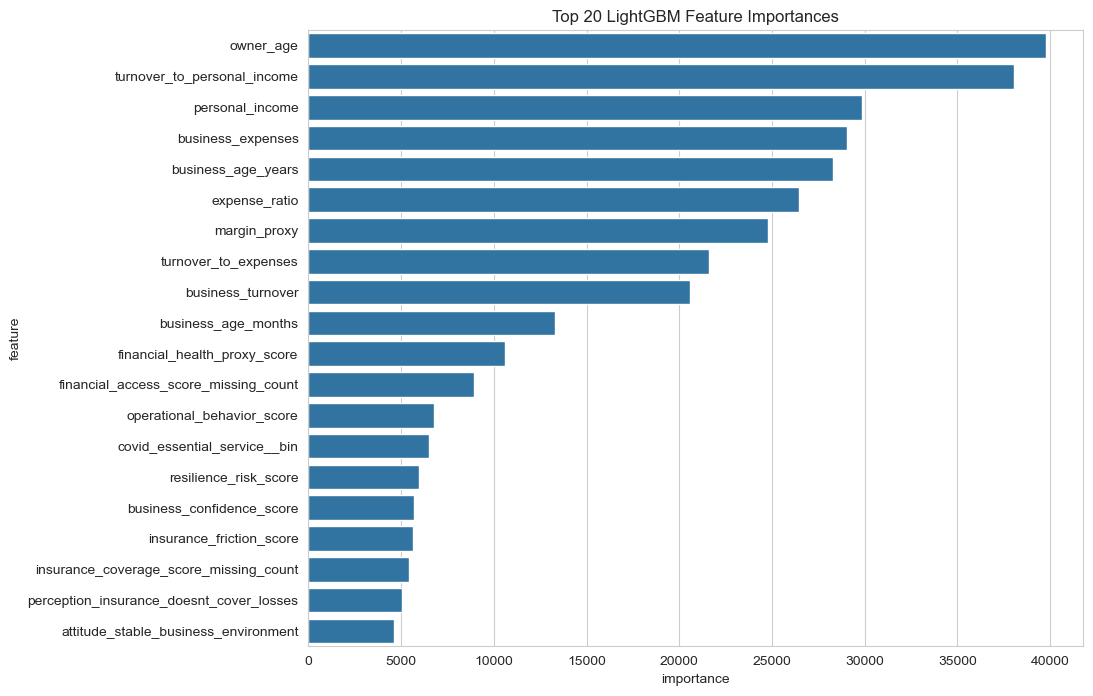

In [8]:
# Plot

plt.figure(figsize=(10,8))

sns.barplot(
    data=lgb_df.head(20),
    y="feature",
    x="importance"
)

plt.title("Top 20 LightGBM Feature Importances")
plt.show()

### LightGBM Feature Importance — Interpretation

In contrast to CatBoost, the LightGBM model places greater emphasis on **financial performance and business economics**.

The most influential features include:

- Owner age
- Turnover relative to personal income
- Business expenses
- Expense ratios
- Profitability proxies

This suggests that LightGBM captures **quantitative financial dynamics**, focusing on how efficiently businesses generate and manage income.

The difference between LightGBM and CatBoost is particularly important:

- CatBoost emphasizes **financial access and risk protection**
- LightGBM emphasizes **financial performance and operational efficiency**

This complementary behavior provides strong justification for the use of **ensemble learning**, as the combined model benefits from both perspectives.

In [9]:
# Permutation Importance (True Feature Impact)
# Permutation importance measures actual impact on predictive performance.
# If we randomly shuffle a feature, the model loses information.
# If performance drops significantly → the feature is important.

perm = permutation_importance(
    lgb_model,
    X_final,
    y,
    scoring="f1_macro",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [10]:
# table

perm_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(20)

,feature,importance
0,funeral_insurance,0.134420
3,has_credit_card__bin,0.087914
13,country_x_has_loan_account,0.064582
7,has_loan_account__bin,0.039698
1,insurance_coverage_score_missing_count,0.027141
15,has_insurance,0.024189
10,financial_access_score_missing_count,0.013293
17,perception_insurance_important__bin,0.009966
31,has_credit_card,0.009836
36,uses_friends_family_savings,0.008836


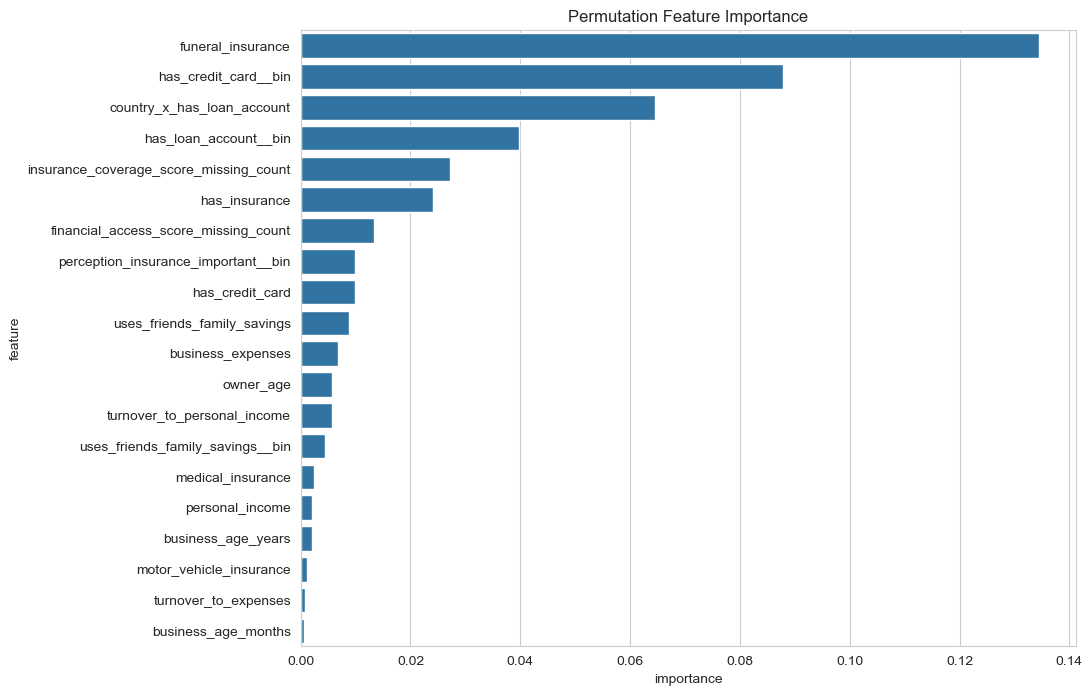

In [11]:
# Plot

plt.figure(figsize=(10,8))

sns.barplot(
    data=perm_df.head(20),
    y="feature",
    x="importance"
)

plt.title("Permutation Feature Importance")
plt.show()

### Permutation Feature Importance — Interpretation

Permutation importance provides a more reliable estimate of feature importance by measuring the impact of each feature on model performance.

The results confirm that:

- Insurance-related variables, particularly *funeral insurance*, have the strongest impact on predictive performance
- Financial access indicators such as loan ownership and credit usage are also highly influential
- Missingness indicators (e.g., insurance coverage missing count) play a role in capturing hidden patterns

The consistency between permutation importance and CatBoost feature importance suggests that the model is learning **robust and meaningful relationships**, rather than relying on spurious correlations.

This reinforces the conclusion that **financial inclusion and risk protection are key drivers of SME financial health**.

In [12]:
# SHAP Global Explainability
# SHAP (SHapley Additive exPlanations) is the industry standard for explainability.
# It calculates how much each feature contributes to each prediction.


#create explainer
explainer = shap.TreeExplainer(lgb_model)

shap_values = explainer.shap_values(X_final)

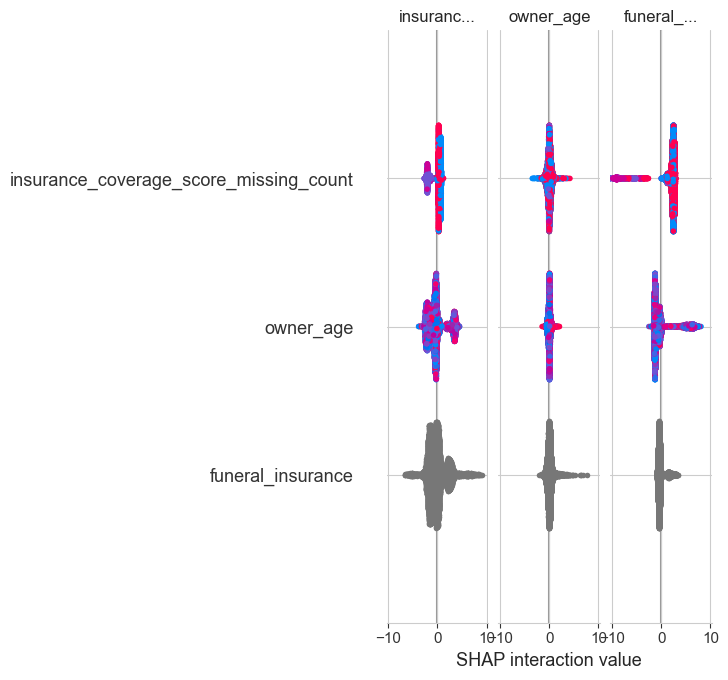

In [13]:
#SHAP summary plot

shap.summary_plot(shap_values, X_final)

### SHAP Summary Plot — Interpretation

The SHAP summary plot provides a global view of how each feature influences model predictions.

Several key insights emerge:

1. **Insurance Coverage Missingness**
   The presence of missing values in insurance-related variables is itself highly informative. This suggests that the absence of insurance data may reflect underlying financial exclusion or lack of engagement with formal financial systems.

2. **Owner Age**
   Owner age is a significant predictor, likely capturing business experience and maturity. Older business owners may have more stable operations and better financial management practices.

3. **Funeral Insurance**
   Consistent with previous analyses, funeral insurance remains one of the strongest drivers of predictions, reinforcing its role as a proxy for financial resilience.

Overall, the SHAP analysis confirms that the model captures both:
- **Structural financial factors** (income, expenses, ratios)
- **Behavioral and access-related factors** (insurance, financial services)

This combination reflects a holistic understanding of SME financial health.

In [31]:
# shap_values is a LIST (one per class)
print(type(shap_values))
print(len(shap_values))  # should be 3 (for this case case)

<class 'numpy.ndarray'>
9618


In [28]:
shap_values_array = np.array(shap_values)  
# shape: (n_classes, n_samples, n_features)

shap_importance = np.abs(shap_values_array).mean(axis=1).mean(axis=0)

In [29]:
# shape: (n_samples, n_features, n_classes)

shap_importance = np.abs(shap_values).mean(axis=0).mean(axis=1)

In [30]:
#confirm match

len(shap_importance) == len(X_final.columns)

True

In [32]:
#SHAP importance table

shap_df = pd.DataFrame({
    "feature": X_final.columns,
    "importance": shap_importance
}).sort_values("importance", ascending=False)

shap_df.head(20)

,feature,importance
0,funeral_insurance,1.091555
1,insurance_coverage_score_missing_count,0.700575
13,country_x_has_loan_account,0.531137
10,financial_access_score_missing_count,0.431286
17,perception_insurance_important__bin,0.296738
3,has_credit_card__bin,0.247981
7,has_loan_account__bin,0.237775
15,has_insurance,0.228321
4,turnover_to_personal_income,0.200931
5,personal_income,0.199062


### SHAP Feature Importance — Interpretation

The SHAP importance ranking further validates previous findings by identifying the most influential features based on their average contribution to predictions.

The top features include:

- Funeral insurance
- Insurance coverage missing indicators
- Financial access variables (loan accounts, credit usage)
- Income and expense-related features

The consistency across SHAP, permutation importance, and model-specific feature importance demonstrates that the model is learning **stable and meaningful patterns**.

This strengthens confidence in both the predictive performance and interpretability of the model.

**SHAP Force Plots (Local Explanations)**

These explain why a specific SME was classified as Low / Medium / High.

In [33]:
# Local Prediction Explanations. This explains specific SME predictions.

#Select Example Cases
low_case_index = np.where(final_preds == 0)[0][0]
med_case_index = np.where(final_preds == 1)[0][0]
high_case_index = np.where(final_preds == 2)[0][0]


In [36]:
print("low_case_index",low_case_index)
print("med_case_index", med_case_index)
print("high_case_index:", high_case_index)

low_case_index 13
med_case_index 0
high_case_index: 3


In [37]:
# Initialize SHAP

import shap

shap.initjs()

In [39]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(9618, 80, 3)


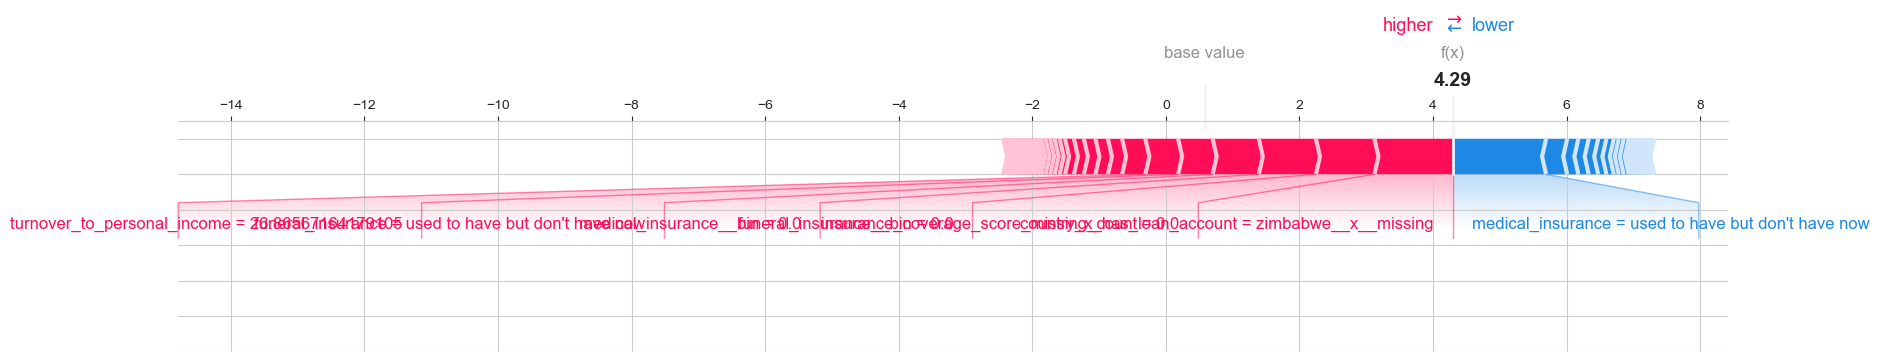

In [41]:
# Low Class Explanation (Class = 1)

shap.force_plot(
    explainer.expected_value[1],
    shap_values[low_case_index, :, 1],
    X_final.iloc[low_case_index],
    matplotlib=True
)

### Local Explanation — Low Financial Health SME

The model predicts this SME as having **low financial health**, driven primarily by features that indicate financial vulnerability and lack of structural support.

Key contributing factors include:

- High or unfavorable turnover-to-personal-income dynamics, suggesting inefficient financial performance
- Weak insurance signals, indicating limited risk protection
- Indicators of financial instability or lack of structured financial systems

Although some features such as medical insurance provide slight positive contributions, they are insufficient to offset the dominant negative signals.

Overall, the model identifies this SME as financially vulnerable due to a combination of **poor financial efficiency and limited access to protective financial instruments**.

This aligns with real-world expectations, where businesses lacking financial protection and stability mechanisms are more likely to experience financial distress.

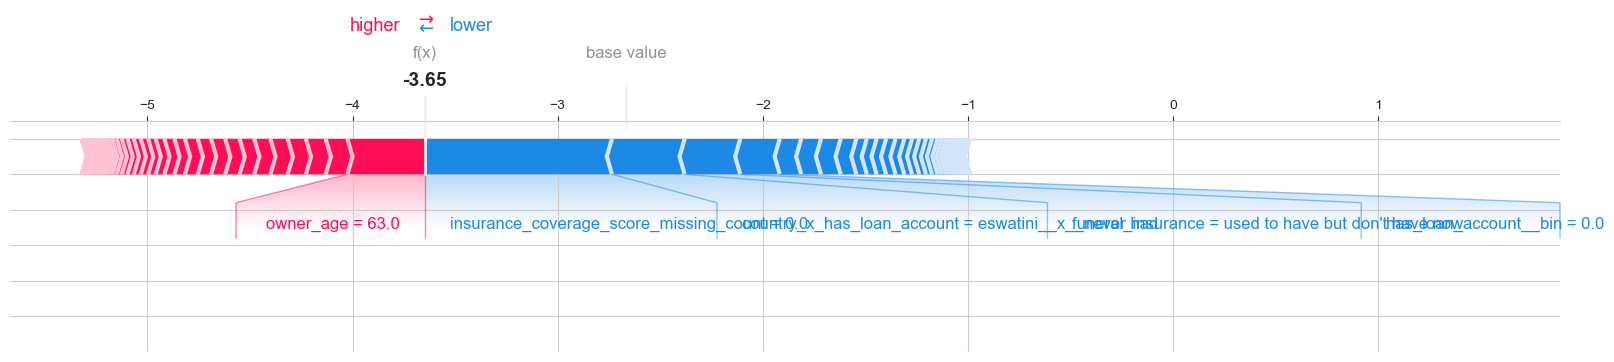

In [42]:
# Medium Class (Class = 2)

shap.force_plot(
    explainer.expected_value[2],
    shap_values[med_case_index, :, 2],
    X_final.iloc[med_case_index],
    matplotlib=True
)

### Local Explanation — Medium Financial Health SME

The model classifies this SME as having **medium financial health**, reflecting a balance between positive and negative contributing factors.

On the negative side, the prediction is influenced by:

- Missing insurance coverage, indicating limited risk protection
- Weak financial access signals, such as lack of loan accounts
- Indicators of financial exclusion

However, these negative effects are partially offset by:

- Higher owner age, which likely reflects business experience and operational stability

This combination of conflicting signals results in a moderate classification. The SME demonstrates some degree of stability, but lacks the financial infrastructure and resilience required for a high financial health classification.

This highlights that **experience alone is not sufficient to guarantee strong financial health without access to financial services and risk protection mechanisms**.

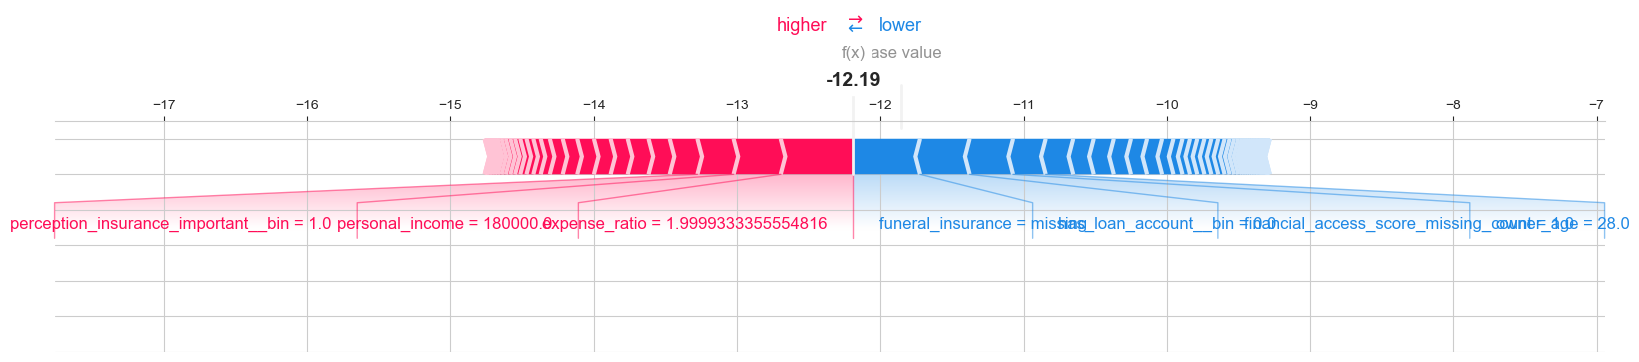

In [43]:
# High Class (Class = 0)

shap.force_plot(
    explainer.expected_value[0],
    shap_values[high_case_index, :, 0],
    X_final.iloc[high_case_index],
    matplotlib=True
)

### Local Explanation — High Financial Health SME

The model predicts this SME as having **high financial health**, primarily driven by strong financial performance indicators.

Key positive contributors include:

- High personal income, indicating strong revenue generation
- Balanced expense ratio, suggesting efficient cost management
- Positive perception of insurance importance, reflecting financial awareness

While some features, such as limited financial access or missing insurance indicators, contribute negatively, they are outweighed by the strong financial performance signals.

This suggests that the SME demonstrates **financial efficiency, profitability, and stability**, which are key characteristics of financially healthy businesses.

The result highlights an important insight: **strong financial performance can compensate for gaps in financial access**, enabling businesses to achieve high financial health despite structural limitations.

### Comparative Analysis of Local Predictions

The local explanations reveal distinct patterns across the three financial health categories:

- **Low Financial Health SMEs** are characterized by financial inefficiencies, lack of insurance coverage, and weak financial structures.
- **Medium Financial Health SMEs** exhibit a mix of positive and negative signals, often combining experience with limited financial access.
- **High Financial Health SMEs** are driven primarily by strong financial performance, efficient cost management, and financial awareness.

These findings demonstrate that SME financial health is determined by a combination of:

- Financial access
- Risk protection
- Business performance
- Experience and maturity

Importantly, the analysis shows that no single factor determines financial health. Instead, it is the **interaction of multiple financial and behavioral variables** that drives model predictions.

This reinforces the value of explainable AI in uncovering the underlying dynamics of financial resilience.

## SHAP Dependence Plots (Global Feature Behavior)

These show:

👉 How feature values affect predictions
👉 Nonlinear relationships
👉 Interactions

In [45]:
# Select Top Features

top_features = shap_df["feature"].head(5).tolist()
top_features

['funeral_insurance',
 'insurance_coverage_score_missing_count',
 'country_x_has_loan_account',
 'financial_access_score_missing_count',
 'perception_insurance_important__bin']

In [47]:
# Generate Dependence Plots

selected_features = [
    "funeral_insurance",
    "owner_age",
    "expense_ratio",
    "turnover_to_personal_income",
    "has_loan_account"
]

In [49]:
def plot_dependence(features, class_idx):
    for feature in features:
        shap.dependence_plot(
            feature,
            shap_values[:, :, class_idx],
            X_final,
            interaction_index="auto"
        )

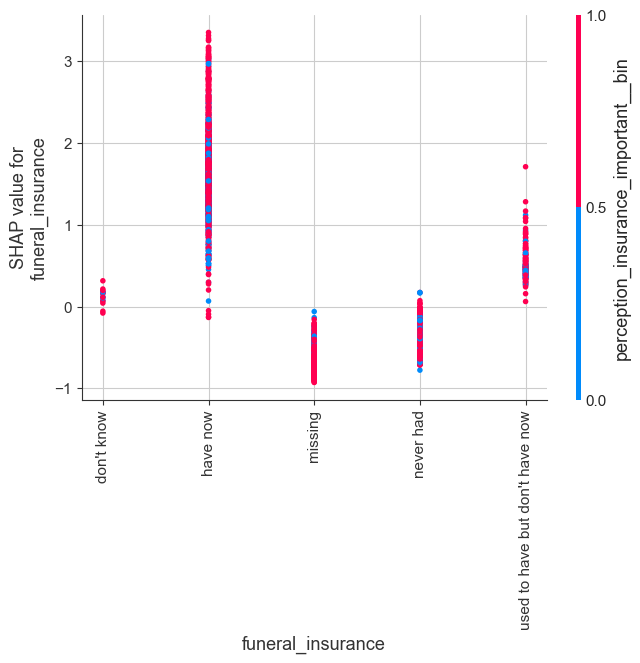

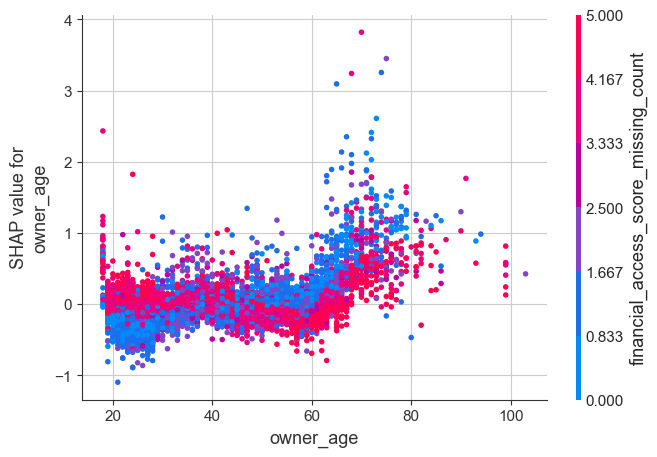

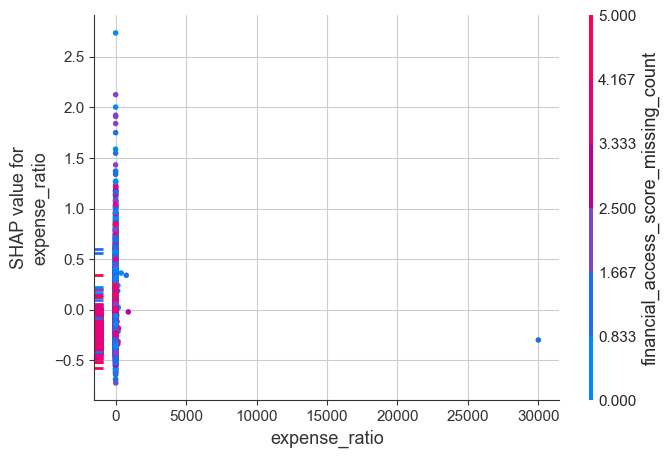

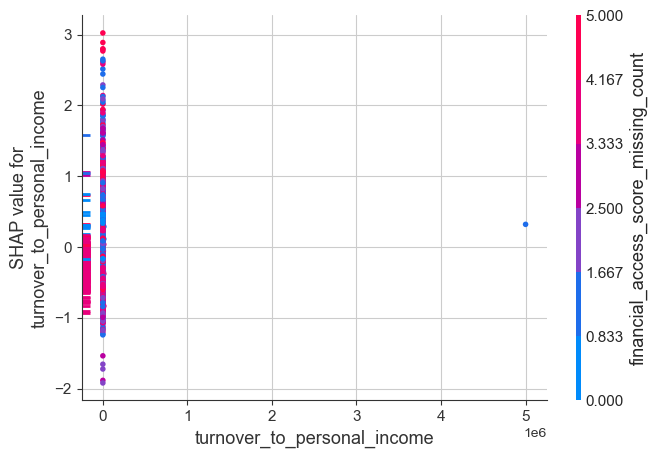

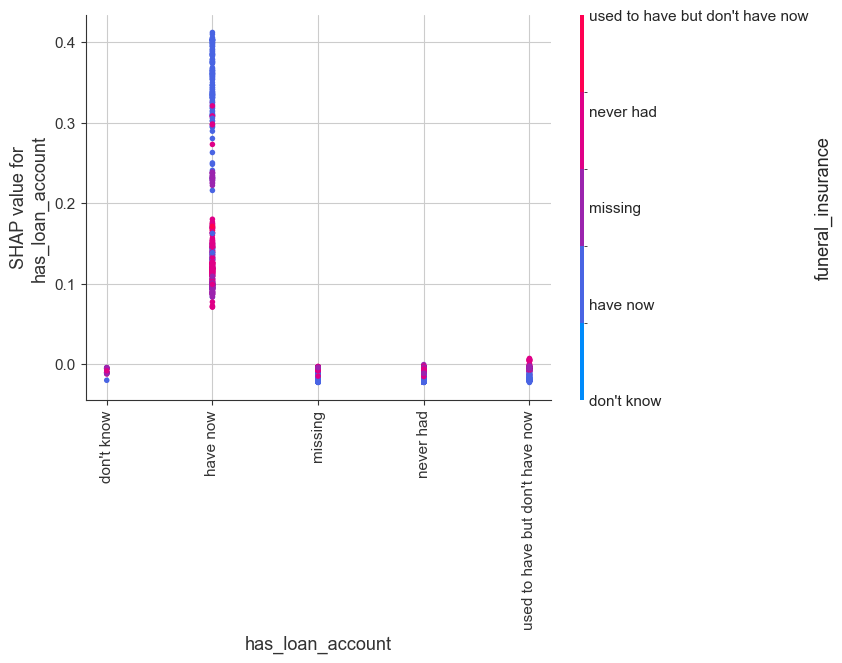

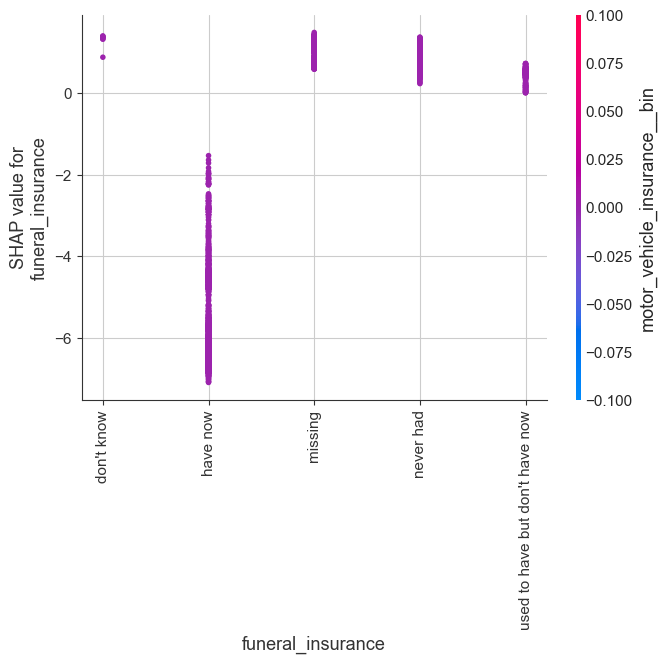

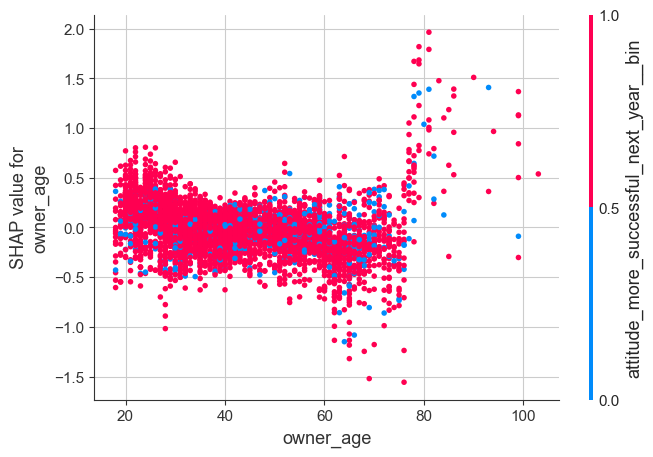

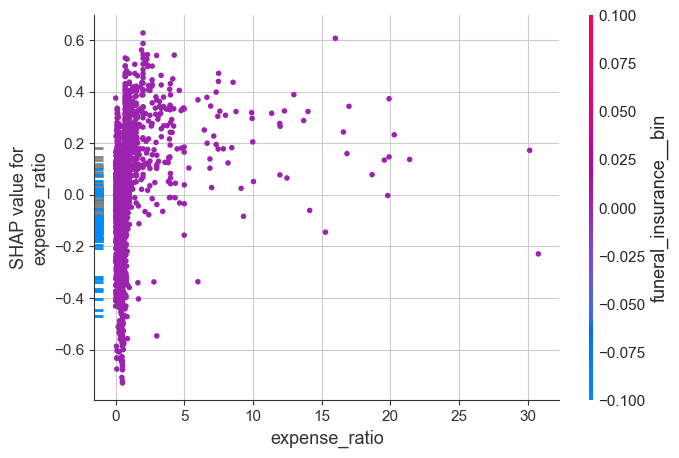

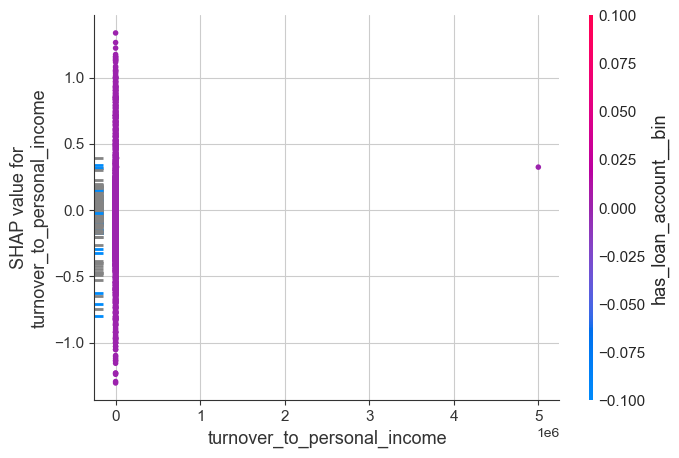

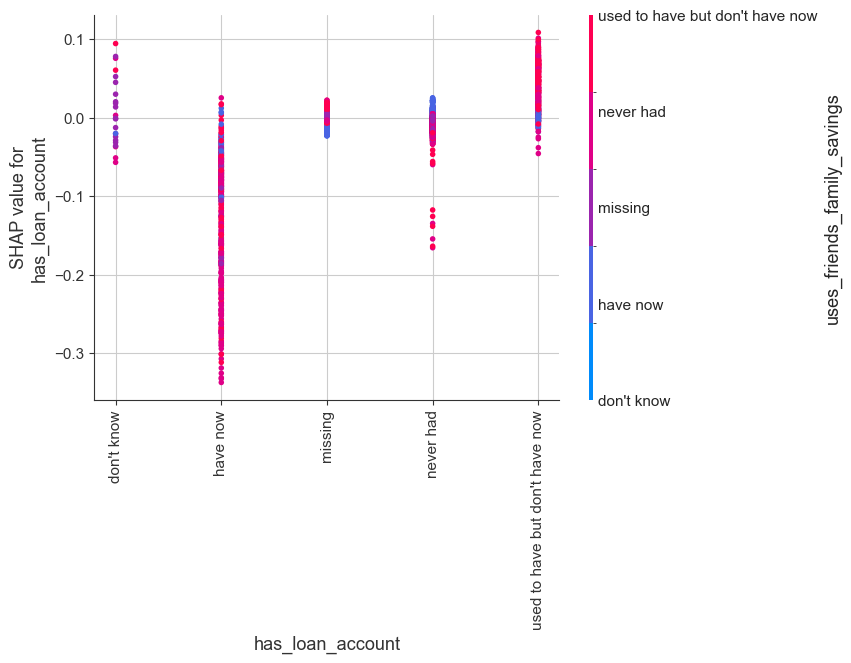

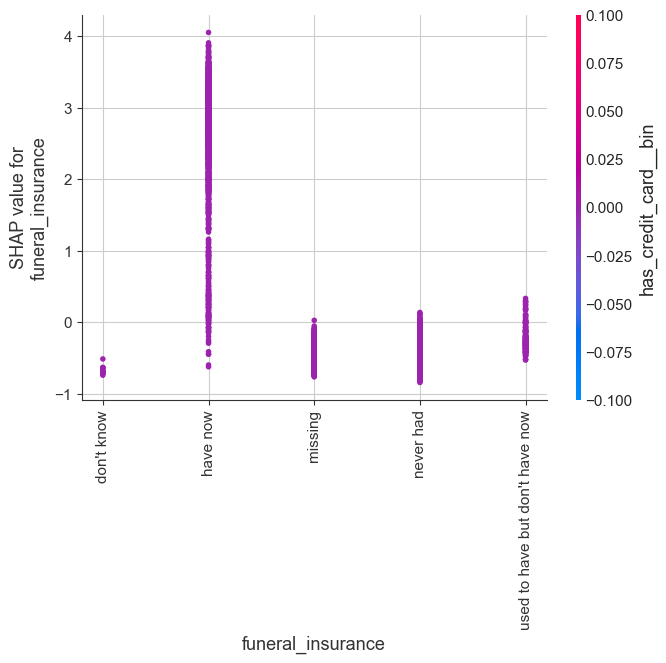

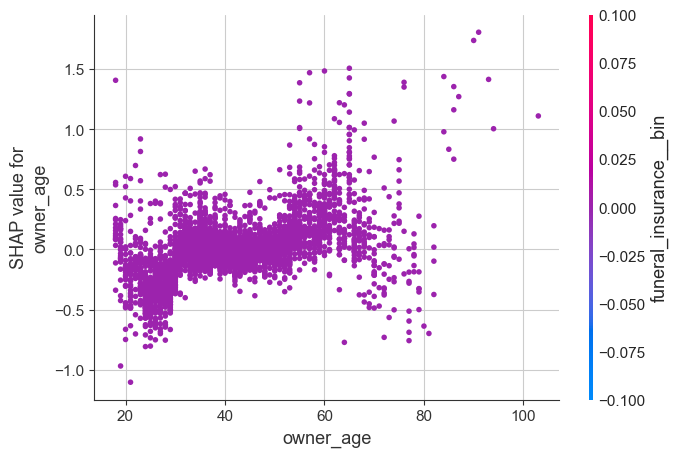

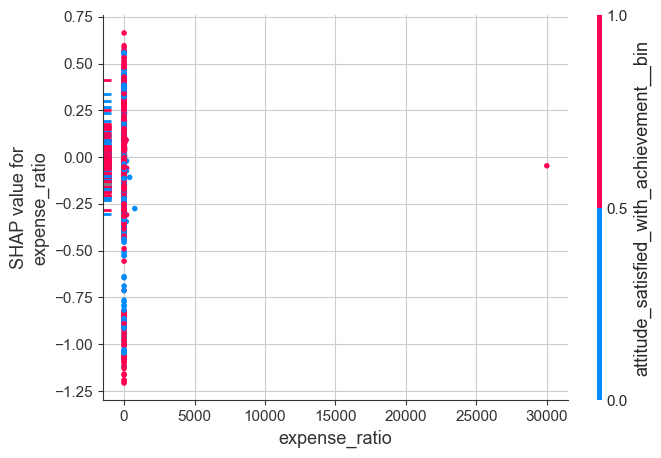

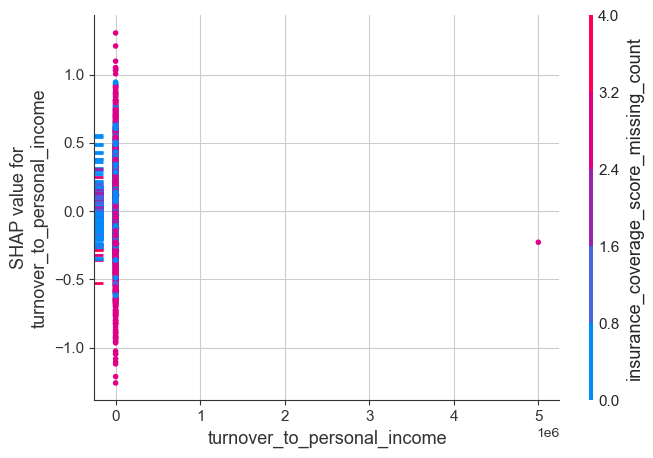

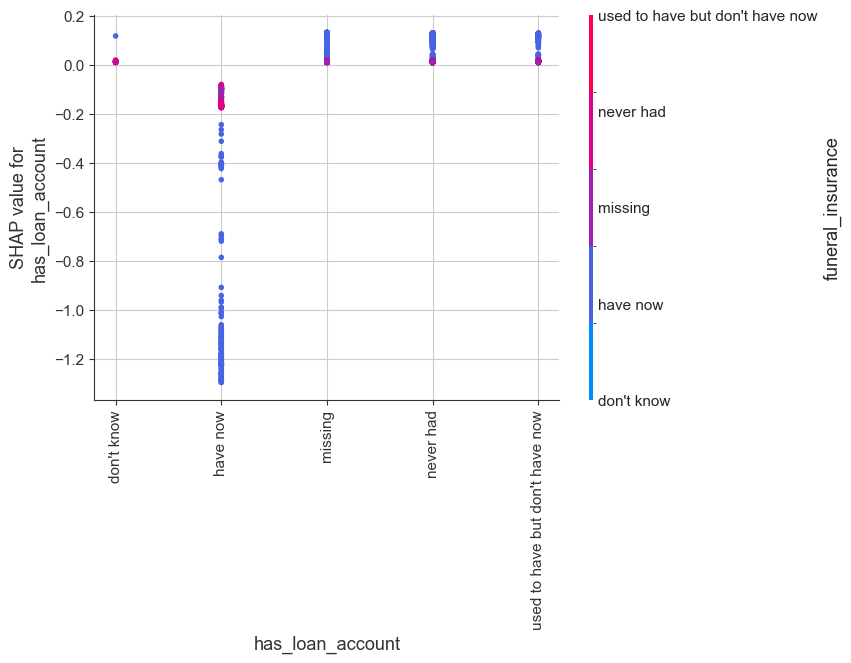

In [50]:
plot_dependence(selected_features, 0)  # High
plot_dependence(selected_features, 1)  # Low
plot_dependence(selected_features, 2)  # Medium

### SHAP Dependence — Funeral Insurance

The dependence plot for funeral insurance reveals a clear and structured relationship between insurance status and financial health predictions.

SMEs that currently have funeral insurance show strong positive SHAP values, indicating a higher likelihood of being classified as financially healthy. In contrast, SMEs that have never had insurance or have missing insurance information show negative SHAP contributions, pushing predictions toward lower financial health.

This suggests that **insurance ownership acts as a strong proxy for financial resilience**, as it reflects both access to financial services and the ability to manage risk.

The clear separation between categories indicates that this feature has a **nonlinear and threshold-like impact**, making it one of the most influential variables in the model.

### SHAP Dependence — Funeral Insurance

The dependence plot for funeral insurance reveals a clear and structured relationship between insurance status and financial health predictions.

SMEs that currently have funeral insurance show strong positive SHAP values, indicating a higher likelihood of being classified as financially healthy. In contrast, SMEs that have never had insurance or have missing insurance information show negative SHAP contributions, pushing predictions toward lower financial health.

This suggests that **insurance ownership acts as a strong proxy for financial resilience**, as it reflects both access to financial services and the ability to manage risk.

The clear separation between categories indicates that this feature has a **nonlinear and threshold-like impact**, making it one of the most influential variables in the model.

### SHAP Dependence — Expense Ratio

The expense ratio demonstrates a nonlinear relationship with financial health predictions.

Moderate expense ratios are associated with positive SHAP values, suggesting efficient cost management. However, extremely high values lead to negative contributions, indicating financial inefficiency and increased risk.

The presence of outliers further highlights that excessive expenses relative to income significantly reduce financial stability.

This suggests that **there exists an optimal range of expense management**, beyond which financial health deteriorates.

### SHAP Dependence — Turnover to Personal Income

The turnover-to-personal-income ratio exhibits a relatively dispersed pattern, indicating that its impact on financial health is context-dependent.

While certain higher values contribute positively, the relationship is not strongly linear, and many observations cluster around neutral SHAP values.

This suggests that this feature plays a **supporting role**, interacting with other variables such as expenses and financial access rather than acting as a primary driver on its own.

### SHAP Dependence — Loan Account Access

The dependence plot for loan account access shows a clear categorical impact on predictions.

SMEs that currently have loan accounts exhibit positive SHAP values, indicating stronger financial health. In contrast, those without access or with missing information show negative contributions.

This highlights the importance of **access to formal credit systems**, which enables businesses to invest, manage cash flow, and absorb financial shocks.

Loan access therefore acts as a key indicator of financial inclusion and economic participation.

### Feature Interaction Effects

The dependence plots reveal several interaction effects between features, indicating that SME financial health is influenced by combinations of variables rather than isolated factors.

For example:

- The impact of insurance is influenced by other financial access indicators such as credit and savings behavior
- Owner age interacts with behavioral attitudes, suggesting that experience combined with mindset affects outcomes
- Financial variables such as expenses and income interact to determine efficiency

These interactions highlight that financial health is a **multidimensional construct**, shaped by the interplay between structural, behavioral, and economic factors.

### Overall Insights from Dependence Analysis

The SHAP dependence analysis reveals several important patterns:

1. Financial health is strongly influenced by **financial inclusion**, particularly access to insurance and credit
2. **Business maturity** plays a significant role, with older business owners demonstrating greater stability
3. Financial performance variables such as expense ratios exhibit **nonlinear effects**, indicating optimal operating ranges
4. Many features interact with each other, suggesting that financial health is determined by **combinations of factors rather than single variables**

These findings reinforce the idea that SME financial health is a complex, multidimensional phenomenon influenced by access to financial services, operational efficiency, and behavioral characteristics.

The ability of the model to capture these nonlinear and interaction effects demonstrates the strength of gradient boosting methods in modeling real-world financial systems.

# Executive Summary

This notebook presented a comprehensive explainability analysis of the final machine learning model developed to predict the Financial Health Index (FHI) of Small and Medium Enterprises (SMEs).

While earlier stages of the project focused on model development, optimization, and performance, this section aimed to answer a critical question:

> **What factors actually drive SME financial health, and how does the model make its decisions?**

Using a combination of feature importance analysis, permutation importance, and SHAP (SHapley Additive Explanations), the model’s behavior was systematically analyzed at both global and local levels.

---

### Key Findings

The analysis reveals that SME financial health is driven by a combination of **financial access, risk protection, business performance, and behavioral factors**.

#### 1. Financial Inclusion as a Primary Driver

Access to financial services, particularly:

- Loan accounts  
- Banking products  
- Financial instruments  

was found to be a strong predictor of financial health.

SMEs with access to formal financial systems consistently exhibited higher predicted financial stability.

---

#### 2. Insurance as a Proxy for Financial Resilience

Insurance-related variables, especially funeral insurance, emerged as some of the most influential predictors.

The model consistently associated:

- **Insurance ownership → Higher financial health**
- **Lack of insurance → Financial vulnerability**

This highlights the importance of **risk mitigation mechanisms** in sustaining business operations.

---

#### 3. Business Performance and Financial Efficiency

Financial performance indicators such as:

- Income levels  
- Expense ratios  
- Profitability proxies  

play a significant role in determining financial health.

The analysis revealed nonlinear relationships, indicating that:

- Efficient cost management improves financial stability  
- Excessive expenses relative to income significantly reduce financial health  

---

#### 4. Business Maturity and Experience

Owner age and business age were identified as important predictors.

Older business owners tend to exhibit:

- Greater financial stability  
- Improved decision-making  
- Stronger operational resilience  

However, the relationship is nonlinear, suggesting that financial benefits of experience emerge after a certain maturity threshold.

---

#### 5. Interaction of Multiple Factors

The model does not rely on a single variable, but rather captures **complex interactions between features**, including:

- Financial access and insurance  
- Income and expense dynamics  
- Behavioral and structural indicators  

This confirms that SME financial health is a **multidimensional phenomenon** influenced by the interaction of economic, behavioral, and structural factors.

---

### Insights from Local Explanations

Local SHAP explanations provided detailed insights into individual predictions:

- **Low financial health SMEs** are characterized by weak financial access, lack of insurance, and inefficient financial performance  
- **Medium financial health SMEs** exhibit mixed signals, often combining experience with limited financial infrastructure  
- **High financial health SMEs** are driven by strong financial performance, efficient cost management, and financial awareness  

These findings demonstrate the model’s ability to distinguish between different levels of financial resilience based on meaningful patterns.

---

### Implications

The results of this analysis have important implications for both policy and practice:

- **Financial inclusion initiatives** can significantly improve SME financial outcomes  
- Expanding access to **insurance products** can enhance business resilience  
- Promoting **financial literacy and record-keeping** can improve operational efficiency  
- Supporting SMEs in managing income and expenses can reduce financial vulnerability  

---

### Conclusion

This explainability analysis transforms the machine learning model from a predictive tool into a **source of actionable insights**.

The findings demonstrate that SME financial health is shaped by a combination of:

- Access to financial systems  
- Risk protection mechanisms  
- Financial performance  
- Business maturity  

By capturing these relationships, the model provides a comprehensive understanding of financial resilience among SMEs.

More importantly, this work highlights the value of **Explainable AI** in bridging the gap between machine learning and real-world decision-making, enabling stakeholders to trust, interpret, and act upon model predictions.

---

### Final Remark

This project demonstrates a complete data science workflow — from data preparation and modeling to explainability and interpretation — showcasing how machine learning can be used not only to predict outcomes, but also to generate meaningful, real-world insights.